<a href="https://colab.research.google.com/github/amathe1/Neural_Networks/blob/main/customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# import statements
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [5]:
# Load dataset
df = pd.read_csv('/content/sample_data/customer_churn_synthetic_1000.csv')

# Separate features and target ( AS last column is output)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1]

In [6]:
# Train, Test data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
# Applying z-score normalization for input data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [8]:
# Casting numpy type of input variables into tensor which ML model can understand
X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))

y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.long)

In [9]:
# Building model
class OverfitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 256),
            nn.Sigmoid(),
            nn.Linear(256, 256),
            nn.Sigmoid(),
            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        return self.net(x)

In [139]:
# Training model
def train_model(model, optimizer, epochs=200):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        pred = model(X_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_test)
            val_loss = criterion(val_pred, y_test.long())

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses


In [11]:
# Train
model1 = OverfitModel()
opt1 = optim.Adam(model1.parameters(), lr=0.01)

train1, test1 = train_model(model1, opt1)

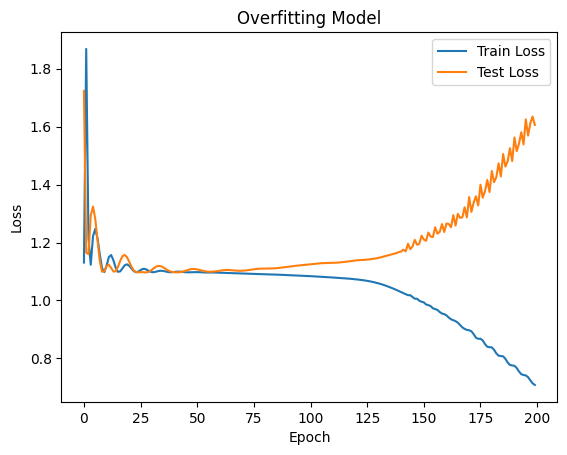

In [140]:
# Plot Loss Curve (Overfitting)
plt.figure()
plt.plot(train1, label="Train Loss")
plt.plot(test1, label="Test Loss")
plt.legend()
plt.title("Overfitting Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

**Regularized model :**

In [135]:
# Regularized model
class RegularizedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 256),
            nn.BatchNorm1d(256),          # Batch Normalization before activation function
            nn.ReLU(),                    # Activation added
            nn.Dropout(0.2),              # Dropout Added
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),          # Batch Normalization before activation function
            nn.ReLU(),                    # Activation added
            nn.Dropout(0.2),              # Dropout Added
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),          # Batch Normalization before activation function
            nn.ReLU(),                    # Activation added
            nn.Dropout(0.2),              # Dropout Added
            nn.Linear(256, 3)
        )

    def forward(self, x):
        return self.net(x)


In [136]:
# Train model
def train_model(model, optimizer, epochs=200, patience=10):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        pred = model(X_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_test)
            val_loss = criterion(val_pred, y_test)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        #  Early Stopping Logic
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    return train_losses, val_losses


In [137]:
# Train
model2 = RegularizedModel()
opt1 = optim.Adam(model2.parameters(), lr=0.01, weight_decay=1e-4)


train2, test2 = train_model(model2, opt1)

print("Training loss :",train2)
print("Testing loss :",test2)


Early stopping at epoch 11
Training loss : [1.158760666847229, 1.4537255764007568, 1.3111988306045532, 1.138853907585144, 1.1512352228164673, 1.118391513824463, 1.0433541536331177, 1.0198416709899902, 1.0533649921417236, 1.0383343696594238, 1.0244635343551636, 0.9940000176429749]
Testing loss : [1.112666368484497, 1.1101772785186768, 1.1320011615753174, 1.143133521080017, 1.157008171081543, 1.1590477228164673, 1.1610383987426758, 1.1770141124725342, 1.1856701374053955, 1.1813879013061523, 1.1875780820846558, 1.214942216873169]


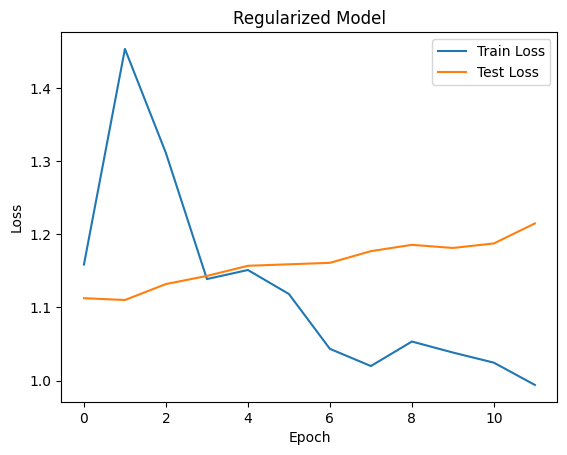

In [138]:
# Plot Loss Curve (Regularized)
plt.figure()
plt.plot(train2, label="Train Loss")
plt.plot(test2, label="Test Loss")
plt.title("Regularized Model - Train Loss")
plt.legend()
plt.title("Regularized Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()